In [ ]:
!pip install --upgrade numpy
!pip install --upgrade pandas
!pip install --upgrade gensim

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using 

In [ ]:
from IPython import get_ipython
from IPython.display import display

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [ ]:
df = pd.read_csv('data.csv', on_bad_lines='skip', quotechar='"')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4657 entries, 0 to 4656
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    4657 non-null   int64 
 1   title    4657 non-null   object
 2   genre    4657 non-null   object
 3   summary  4657 non-null   object
dtypes: int64(1), object(3)
memory usage: 145.7+ KB


# Preprocessing

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
processed_summaries = []
for text in df['summary']:
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    processed_summaries.append(tokens)

processed_summaries[:3]

[['drowned',
  'wednesday',
  'first',
  'trustee',
  'among',
  'morrow',
  'day',
  'arthur',
  'side',
  'wish',
  'fulfilled',
  'appears',
  'leviathanwhale',
  'suffers',
  'gluttony',
  'book',
  'begin',
  'leaf',
  'visiting',
  'arthur',
  'discussing',
  'invitation',
  'drowned',
  'wednesday',
  'sent',
  'arthur',
  'admitted',
  'hospital',
  'damage',
  'done',
  'leg',
  'attempted',
  'enter',
  'tuesday',
  'treasure',
  'tower',
  'suddenly',
  'hospital',
  'room',
  'becomes',
  'flooded',
  'water',
  'two',
  'transported',
  'border',
  'sea',
  'house',
  'leaf',
  'snatched',
  'away',
  'large',
  'ship',
  'green',
  'sail',
  'known',
  'flying',
  'mantis',
  'arthur',
  'remains',
  'bed',
  'medallion',
  'given',
  'immortal',
  'called',
  'mariner',
  'apparently',
  'fails',
  'summon',
  'help',
  'arthur',
  'without',
  'hope',
  'eventually',
  'buoy',
  'marking',
  'pirate',
  'elishar',
  'feverfew',
  'treasure',
  'float',
  'toward',
  'so

# Training Word2Vec

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences = processed_summaries,
    vector_size = 100,
    window = 5,
    min_count = 2,
    workers = 4,
    sg=1
)

vocab_size = len(w2v_model.wv.index_to_key)
print(f"Word2Vec model trained with vocab size: {vocab_size}")

Word2Vec model trained with vocab size: 34050


In [ ]:
if 'magic' in w2v_model.wv:
    print("\nTop similar words to 'magic':")
    for word, sim in w2v_model.wv.most_similar('magic'):
        print(f"{word:<15} {sim:.2f}")


Top similar words to 'magic':
magical         0.84
spell           0.79
demon           0.77
power           0.75
summon          0.74
realm           0.74
gem             0.73
aura            0.72
amulet          0.72
wizard          0.72


# DL and load GloVe

##### GloVe (Global Vectors for Word Representation)


*   Type: Static word embedding
*   Architecture: Matrix factorization of word co-occurence matrix
*   Training corpus: Common Crawl (840B tokens) or Wikipedia/Gigaword (6B tokens)
*   Dimensions used: 100-dim vectors (.txt file path two cells below)
*   Key features: Captures global co-occurence stats of words across entire corpus



In [ ]:
import zipfile
import os
import requests
from tqdm import tqdm

In [ ]:
glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_zip_path = "glove.6B.zip"
glove_txt_path = "glove.6B.100d.txt"

In [ ]:
if not os.path.exists(glove_txt_path):
    response = requests.get(glove_url, stream=True)
    with open(glove_zip_path, "wb") as f:
        for chunk in tqdm(response.iter_content(chunk_size=1024)):
            if chunk:
                f.write(chunk)

    # Step 2: Extract only 100D vectors file
    with zipfile.ZipFile(glove_zip_path, 'r') as zip_ref:
        zip_ref.extract("glove.6B.100d.txt")

841976it [04:28, 3132.13it/s]


In [ ]:
glove_embeddings = {}
with open(glove_txt_path, "r", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = list(map(float, values[1:]))
        glove_embeddings[word] = vector

print("GloVe embeddings loaded.")
print(f"Total words in GloVe: {len(glove_embeddings):,}")

GloVe embeddings loaded.
Total words in GloVe: 400,000


# Load Transformer-based embeddings

##### MiniLM

*    Model: all-MiniLM-L6-v2 (SentenceTransformers)
*    Architecture: Distilled transformer, 6 layers, based on BERT/DistilBERT
*    Training Source: Pretrained on large datasets (Wikipedia/BooksCorpus) and fine-tuned on Semantic Textual Similarity (STS) and NLI datasets
*    Output: 384-dim sentence-level embeddings
*    Key features: Contextual, dynamic word/sentence represetations sensitive to order and phrasing

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
from sentence_transformers import SentenceTransformer


transformer_model = SentenceTransformer('all-MiniLM-L6-v2')


embedding = transformer_model.encode("magic")
print("Transformer embedding ready (dimension):", len(embedding))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Transformer embedding ready (dimension): 384


# Semantic Distance comparison

In [ ]:
words = [
    "magic", "spell", "dragon", "sword", "quest",

    "computer", "hospital", "school", "money", "science"
]


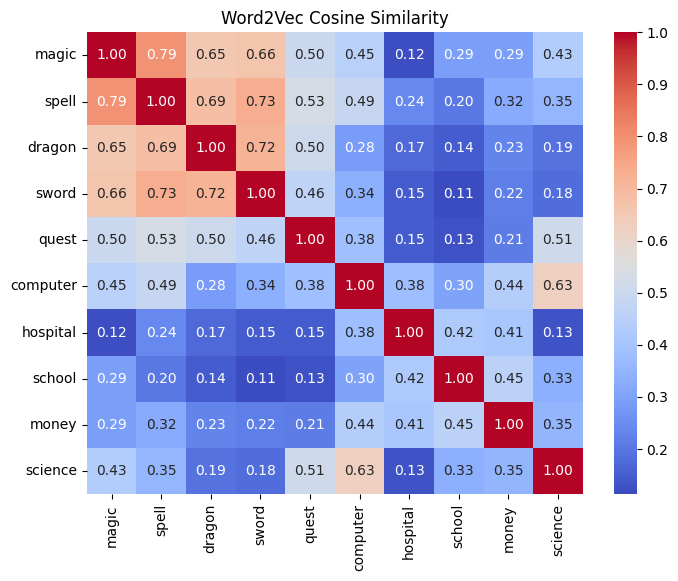

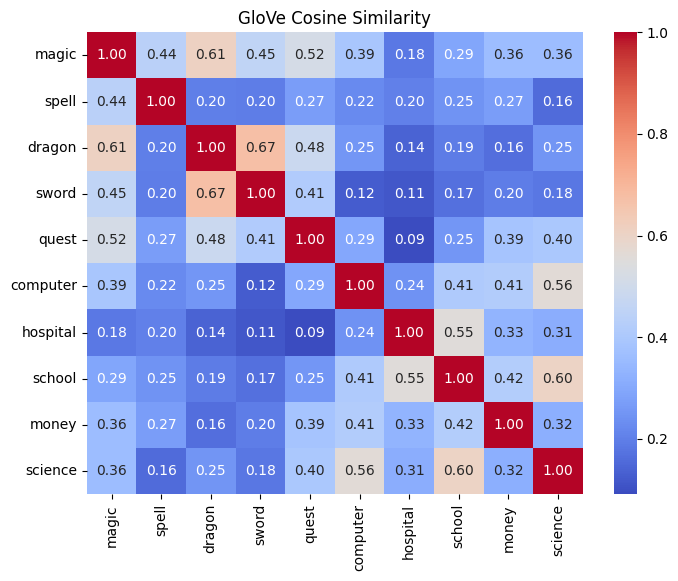

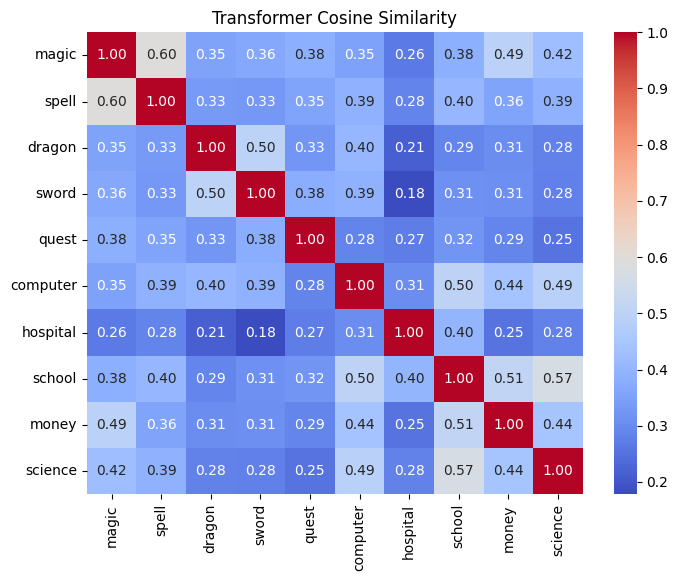

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

def get_vector(model_type, word):
    if model_type == "w2v":
        return w2v_model.wv[word] if word in w2v_model.wv else np.zeros(100)
    elif model_type == "glove":
        return glove_embeddings[word] if word in glove_embeddings else np.zeros(100)
    elif model_type == "transformer":
        return transformer_model.encode(word)
    return np.zeros(100)

w2v_vecs = np.array([get_vector("w2v", w) for w in words])
glove_vecs = np.array([get_vector("glove", w) for w in words])
transformer_vecs = np.array([get_vector("transformer", w) for w in words])

# cosine similarity
w2v_sim = cosine_similarity(w2v_vecs)
glove_sim = cosine_similarity(glove_vecs)
transformer_sim = cosine_similarity(transformer_vecs)

def plot_heatmap(sim_matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title(title)
    plt.show()

plot_heatmap(w2v_sim, "Word2Vec Cosine Similarity")
plot_heatmap(glove_sim, "GloVe Cosine Similarity")
plot_heatmap(transformer_sim, "Transformer Cosine Similarity")


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x78ee82723b00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


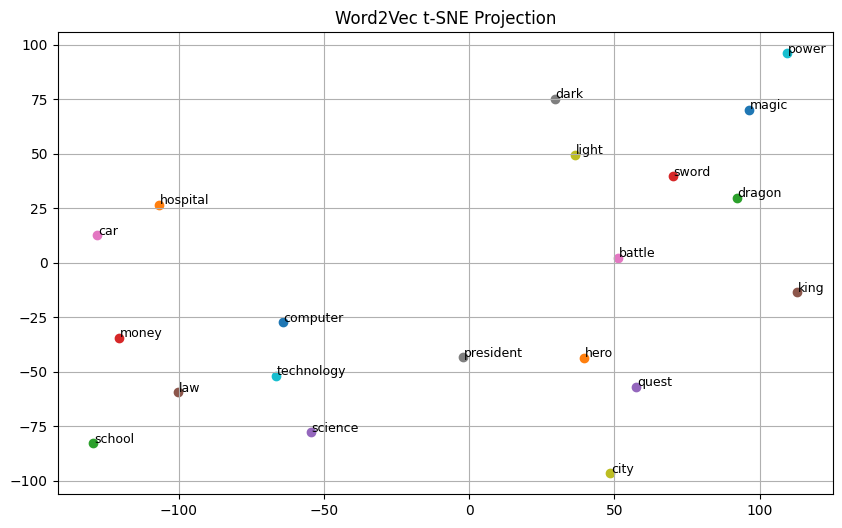

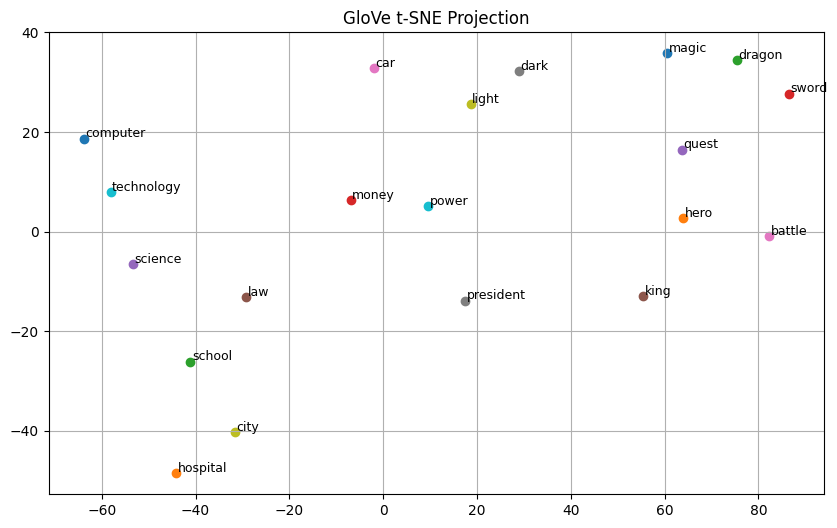

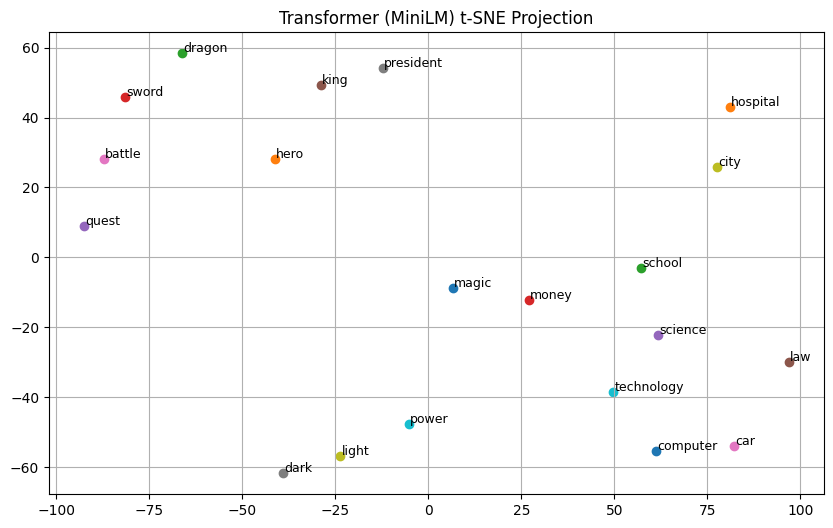

In [ ]:
from sklearn.manifold import TSNE

words = [
    "magic", "hero", "dragon", "sword", "quest",
    "king", "battle", "dark", "light", "power",
    "computer", "hospital", "school", "money", "science",
    "law", "car", "president", "city", "technology"
]

# grabbing embedding vectors from each model
w2v_vecs = np.array([get_vector("w2v", w) for w in words])
glove_vecs = np.array([get_vector("glove", w) for w in words])
transformer_vecs = np.array([get_vector("transformer", w) for w in words])

# reducing to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
w2v_2d = tsne.fit_transform(w2v_vecs)
glove_2d = tsne.fit_transform(glove_vecs)
transformer_2d = tsne.fit_transform(transformer_vecs)

def plot_tsne(coords, title):
    plt.figure(figsize=(10, 6))
    for i, word in enumerate(words):
        x, y = coords[i]
        plt.scatter(x, y)
        plt.text(x + 0.3, y + 0.3, word, fontsize=9)
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_tsne(w2v_2d, "Word2Vec t-SNE Projection")
plot_tsne(glove_2d, "GloVe t-SNE Projection")
plot_tsne(transformer_2d, "Transformer (MiniLM) t-SNE Projection")


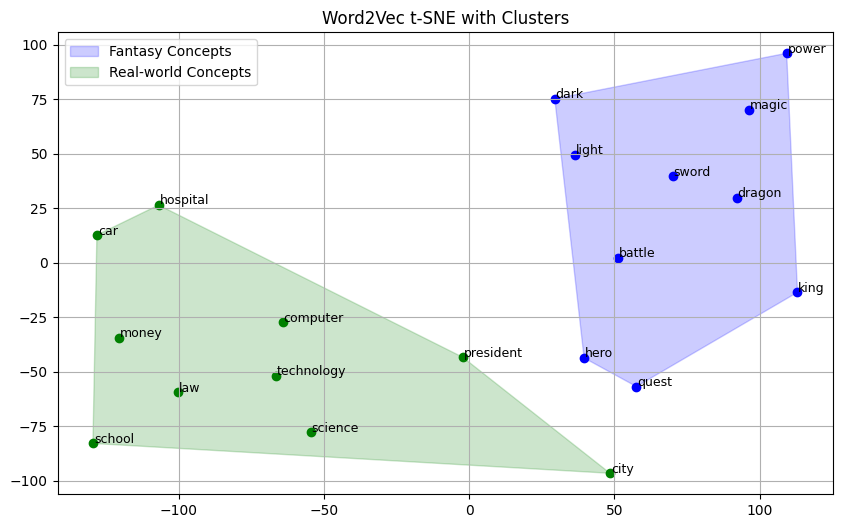

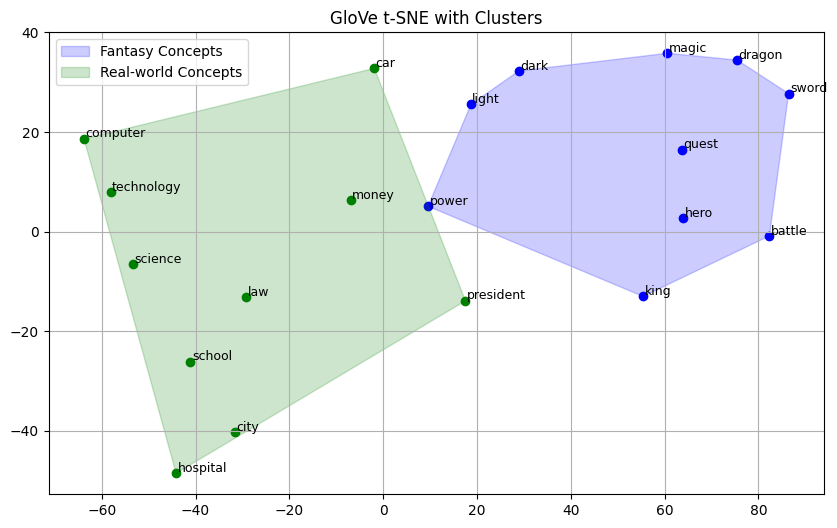

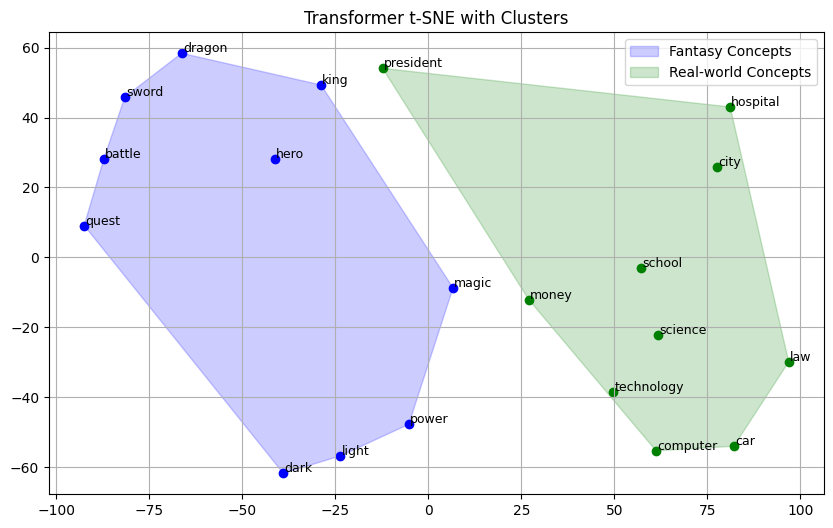

In [ ]:
from scipy.spatial import ConvexHull
import matplotlib.patches as patches

def plot_tsne_clusters(coords, title):
    plt.figure(figsize=(10, 6))

    # indices from the word list
    fantasy_idx = list(range(10))
    real_idx = list(range(10, 20))

    # plotting the words
    for i, word in enumerate(words):
        x, y = coords[i]
        plt.scatter(x, y, color='blue' if i in fantasy_idx else 'green')
        plt.text(x + 0.3, y + 0.3, word, fontsize=9)

    # drawing convex hull around the clusters
    def draw_cluster(indices, color, label):
        points = coords[indices]
        if len(points) >= 3:
            hull = ConvexHull(points)
            polygon = patches.Polygon(points[hull.vertices], alpha=0.2, color=color, label=label)
            plt.gca().add_patch(polygon)

    draw_cluster(fantasy_idx, 'blue', 'Fantasy Concepts')
    draw_cluster(real_idx, 'green', 'Real-world Concepts')

    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# plot
plot_tsne_clusters(w2v_2d, "Word2Vec t-SNE with Clusters")
plot_tsne_clusters(glove_2d, "GloVe t-SNE with Clusters")
plot_tsne_clusters(transformer_2d, "Transformer t-SNE with Clusters")


## Test 1: Clustering

In [ ]:
genre_counts = df['genre'].value_counts()

# sample 50 summaries each from the top 5 genres for diversity
sampled_df = pd.concat([
    df[df['genre'] == genre].sample(100, random_state=42)
    for genre in genre_counts.head(5).index
])

# display included genres
sampled_df['genre'].value_counts()

,count
genre,
thriller,100
fantasy,100
science,100
history,100
horror,100


In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


# 1. Word2Vec Embeddings (mean of token vectors)
w2v_embeds = []
for summary in sampled_df['summary']: # Iterate over the 'summary' column
    tokens = word_tokenize(summary.lower())
    vectors = [w2v_model.wv[w] for w in tokens if w in w2v_model.wv]
    vec = np.mean(vectors, axis=0) if vectors else np.zeros(100)
    w2v_embeds.append(vec)

# 2. GloVe Embeddings
glove_embeds = []
for summary in sampled_df['summary']: # Iterate over the 'summary' column
    tokens = word_tokenize(summary.lower())
    vectors = [glove_embeddings[w] for w in tokens if w in glove_embeddings]
    vec = np.mean(vectors, axis=0) if vectors else np.zeros(100)
    glove_embeds.append(vec)

# 3. Transformer Embeddings
transformer_embeds = transformer_model.encode(list(sampled_df['summary']), show_progress_bar=True) # Encode the 'summary' column

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

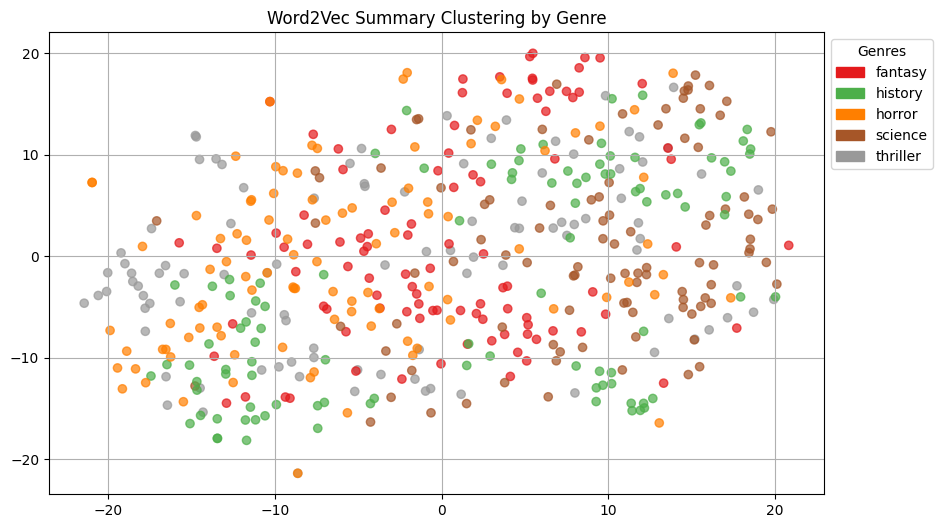

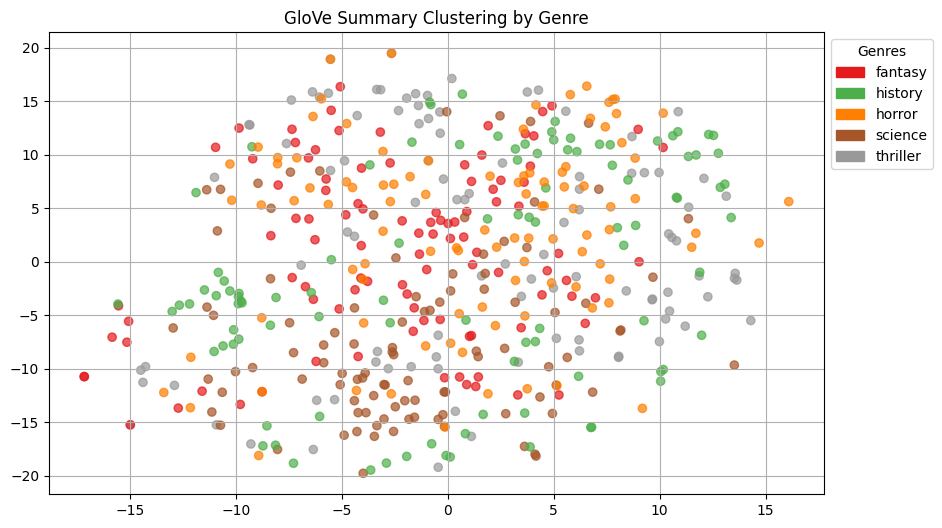

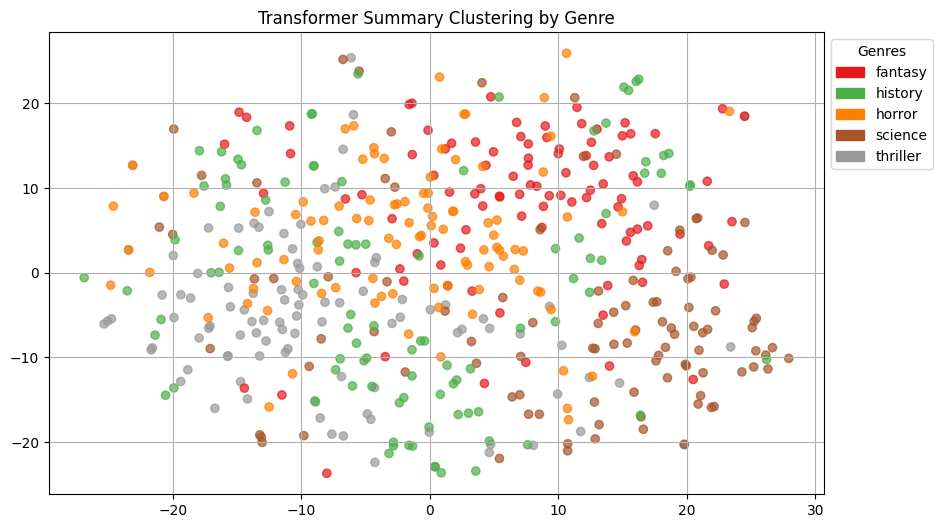

In [ ]:
from sklearn.preprocessing import LabelEncoder

genres = sampled_df['genre']
label_encoder = LabelEncoder()
genre_labels = label_encoder.fit_transform(genres)

# KMeans for each embedding
kmeans_w2v = KMeans(n_clusters=len(set(genre_labels)), random_state=42).fit(w2v_embeds)
kmeans_glove = KMeans(n_clusters=len(set(genre_labels)), random_state=42).fit(glove_embeds)
kmeans_tr = KMeans(n_clusters=len(set(genre_labels)), random_state=42).fit(transformer_embeds)

w2v_array = np.array(w2v_embeds)
glove_array = np.array(glove_embeds)
tr_array = np.array(transformer_embeds)

w2v_2d = TSNE(n_components=2, random_state=42).fit_transform(w2v_array)
glove_2d = TSNE(n_components=2, random_state=42).fit_transform(glove_array)
tr_2d = TSNE(n_components=2, random_state=42).fit_transform(tr_array)

def plot_clusters(emb_2d, genre_labels, genre_names, title):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        emb_2d[:, 0], emb_2d[:, 1],
        c=genre_labels, cmap='Set1', alpha=0.7
    )

    # legend with genre names
    handles = []
    for i, genre in enumerate(genre_names):
        color = scatter.cmap(scatter.norm(i))
        handles.append(mpatches.Patch(color=color, label=genre))

    plt.legend(handles=handles, title="Genres", loc="best", bbox_to_anchor=(1, 1))
    plt.title(title)
    plt.grid(True)
    plt.show()

genre_names = label_encoder.classes_  # ['fantasy', 'history', 'horror', 'science', 'thriller']

plot_clusters(w2v_2d, genre_labels, genre_names, "Word2Vec Summary Clustering by Genre")
plot_clusters(glove_2d, genre_labels, genre_names, "GloVe Summary Clustering by Genre")
plot_clusters(tr_2d, genre_labels, genre_names, "Transformer Summary Clustering by Genre")


## Test 2: BiDirectional LSTM with and without GloVe embeddings

In [ ]:
# WORKING ON IT -QUINN